In [8]:
#Part of this notebook is based on https://github.com/kristinakobrock/context-shapes-language
from utils.load_results import *
from utils.plot_helpers import *

import pandas as pd
#import seaborn as sns
from matplotlib import pyplot as plt
plt.style.use('default')
import torch
from utils.analysis_from_interaction import *
from language_analysis_local import TopographicSimilarityConceptLevel, encode_target_concepts_for_topsim
import os
if not os.path.exists('analysis'):
    os.makedirs('analysis')
#import plotly.express as px

In [9]:
datasets = ['(3,4)', '(3,8)', '(3,16)', '(4,4)', '(4,8)', '(5,4)']
n_values = [4, 8, 16, 4, 8, 4]
n_attributes = [3, 3, 3, 4, 4, 5]
n_epochs = 300
n_datasets = len(datasets)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [10]:
context_unaware = False # whether original or context_unaware simulations are evaluated

setting = 'standard'
granularity_list = ['coarse',  'sampled_context', 'fine']
#non_default_gran_list = ['coarse', 'fine']

### Determine vocab size

In [13]:
import os
import csv
from collections import Counter
import torch

output_folder = 'analysis'
csv_filename = os.path.join(output_folder, '00_vocab_sizes.csv')

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

fieldnames = ['dataset', 'context_condition', 'run', 'vocab_size', 'symbols']
file_exists = os.path.exists(csv_filename)

context_name_map = {
    'coarse': 'coarse',
    'fine': 'fine',
    'sampled_context': 'mixed',
    'mixed': 'mixed_full',
}

def get_run_path(base_path, setting, g, run):
    if g == 'mixed':
        return base_path + '/' + str(setting) + '/' + str(run) + '/'

    elif g == 'sampled_context':
        return base_path + '/' + str(setting) + '/sampled_context/' + str(run) + '/'

    else:
        return base_path + '/' + str(setting) + '/granularity_' + g + '/' + str(run) + '/'

with open(csv_filename, 'a', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    if not file_exists:
        writer.writeheader()

    for i, d in enumerate(datasets):
        for g in granularity_list:

            context_label = context_name_map.get(g, g)

            for run in range(5):

                path_to_run = get_run_path(
                    base_path=paths[i],
                    setting=setting,
                    g=g,
                    run=run
                )

                path_to_interaction_train = (
                    path_to_run
                    + 'interactions/train/epoch_'
                    + str(n_epochs)
                    + '/interaction_gpu0'
                )

                if not os.path.exists(path_to_interaction_train):
                    print(f"Missing file, skipping: {path_to_interaction_train}")
                    continue

                interaction = torch.load(path_to_interaction_train)

                messages = interaction.message.argmax(dim=-1)
                messages = [msg.tolist() for msg in messages]

                all_symbols = [
                    symbol
                    for message in messages
                    for symbol in message
                ]

                symbol_counts = Counter(all_symbols)
                vocab_size = len(symbol_counts)

                writer.writerow({
                    'dataset': d,
                    'context_condition': context_label,
                    'run': run,
                    'vocab_size': vocab_size,
                    'symbols': symbol_counts
                })

In [14]:
import pandas as pd
df = pd.read_csv('analysis/00_vocab_sizes.csv')
df

,dataset,context_condition,run,vocab_size,symbols
0,"(3,4)",coarse,0,11,"Counter({0: 742, 4: 433, 7: 394, 3: 370, 13: 3..."
1,"(3,4)",coarse,1,11,"Counter({0: 742, 4: 427, 2: 352, 7: 327, 3: 25..."
2,"(3,4)",coarse,2,14,"Counter({0: 742, 13: 400, 15: 293, 14: 283, 6:..."
3,"(3,4)",coarse,3,9,"Counter({0: 742, 4: 414, 8: 390, 5: 367, 13: 3..."
4,"(3,4)",coarse,4,10,"Counter({0: 742, 15: 392, 9: 389, 5: 341, 4: 2..."
...,...,...,...,...,...
85,"(5,4)",fine,0,16,"Counter({0: 18742, 15: 17942, 5: 14368, 11: 13..."
86,"(5,4)",fine,1,16,"Counter({0: 18742, 2: 12071, 8: 9519, 4: 8860,..."
87,"(5,4)",fine,2,16,"Counter({0: 18742, 4: 13127, 1: 9972, 11: 8421..."
88,"(5,4)",fine,3,16,"Counter({0: 18742, 14: 11891, 1: 11523, 5: 831..."


### See which messages are produced for which concepts

In [ ]:
# go through all datasets
for i, d in enumerate(datasets):
    for g in granularity_list:
        if g != 'mixed':
        # select first run
            path_to_run = paths[i] + '/' + str(setting) +'/granularity_' + g +'/' + str(0) + '/'
        else:
            path_to_run = paths[i] + '/' + str(setting) +'/' + str(0) + '/'
            
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction_train)
        print(path_to_interaction_train)

        messages = interaction.message.argmax(dim=-1)
        messages = [msg.tolist() for msg in messages]
        sender_input = interaction.sender_input
        print(sender_input.shape)
        n_targets = int(sender_input.shape[1]/2)
        # get target objects and fixed vectors to re-construct concepts
        target_objects = sender_input[:, :n_targets]
        target_objects = k_hot_to_attributes(target_objects, n_values[i])
        # concepts are defined by a list of target objects (here one sampled target object) and a fixed vector
        (objects, fixed) = retrieve_concepts_sampling(target_objects, all_targets=True)
        concepts = list(zip(objects, fixed))

        # get distractor objects to re-construct context conditions
        distractor_objects = sender_input[:, n_targets:]
        distractor_objects = k_hot_to_attributes(distractor_objects, n_values[i])
        context_conds = retrieve_context_condition(objects, fixed, distractor_objects)
        #print(context_conds)

        # get random qualitative samples
        #fixed_index = random.randint(0, n_attributes[i]-1) # define a fixed index for the concept
        n_fixed = random.randint(1, n_attributes[i]) # how many fixed attributes?
        #n_fixed = 3
        fixed_indices = random.sample(range(0, n_attributes[i]), k=n_fixed) # select which attributes are fixed
        #fixed_indices = [0, 2, 1]
        #fixed_value = random.randint(0, n_values[i]-1) # define a fixed value for this index
        fixed_values = random.choices(range(0, n_values[i]), k=n_fixed)
        #fixed_values = [0, 1, 2]
        print(n_fixed, fixed_indices, fixed_values)
        #index_threshold = 20000 # optional: define some index threshold to make sure that examples are not taken from the beginning of training
        # TODO: adapt this loop such that multiple indices can be fixed
        all_for_this_concept = []
        for idx, (t_objects, t_fixed) in enumerate(concepts):
            #if sum(t_fixed) == 1 and t_fixed[fixed_index] == 1:# and idx > index_threshold:
            if sum(t_fixed) == n_fixed and all(t_fixed[fixed_index] == 1 for fixed_index in fixed_indices):
                for t_object in t_objects:
                    if all(t_object[fixed_index] == fixed_values[j] for j, fixed_index in enumerate(fixed_indices)):
                        all_for_this_concept.append((idx, t_object, t_fixed, context_conds[idx], messages[idx]))
                        fixed = t_fixed
        #print(all_for_this_concept)                
        if len(all_for_this_concept) > 0:
            #sample = random.sample(all_for_this_concept, 20)
            sample = all_for_this_concept
            column_names = ['game_nr', 'object', 'fixed indices', 'context condition', 'message']
            df = pd.DataFrame(sample, columns=column_names)
            df.to_csv('analysis/quali_' + str(d) + '_' + str(setting) + '_'+g +'_' + str(sample[0][1]) + ',' + str(fixed) + 'all.csv', index=False)
            print('saved ' + 'analysis/quali_' + str(d) + '_' + str(setting) +'_' + g + '_' + str(sample[0][1]) + ',' + str(fixed) + 'all.csv')
        else:
            raise ValueError("sample for dataset " + str(d) + g + " could not be generated")

### Count messages used for each dataset

In [15]:
def create_alternative_representation(concept):
        '''
        this function allows to create an alternative represenation for concepts that is completely aequivent to the one 
        used until now, but may come in handy for comparisons bewteen concepts.

        Args:
            concept : a concept is the form usual form (objects, fixed)
        
        Returns:
            tuple : the same concept in an alternative represenation, where non-fixed attributes are represented as '?'.

        Examples:
           >>> create_alternative_represenantion(([(1, 2, 2), (1, 2, 1), (1, 2, 0)], (1, 1, 0)))
            (1, 2, '?')
        '''
        obj, fixed = concept
        new_obj = [
            value if is_fixed else '?' 
            for value, is_fixed in zip(obj, fixed)
        ]
        #rep = (((new_obj), (fixed)))
        rep = tuple(new_obj)

        return rep

In [17]:
import csv
import os
import torch

analysis_folder = 'analysis'
csv_filename = os.path.join(analysis_folder, 'message_counts.csv')

if not os.path.exists(analysis_folder):
    os.makedirs(analysis_folder)

fieldnames = [
    'dataset',
    'context_condition',
    'run',
    'unique_messages',
    'unique_concepts',
    'messages/concepts'
]

context_name_map = {
    'coarse': 'coarse',
    'fine': 'fine',
    'sampled_context': 'mixed',
    'mixed': 'mixed_full',
}


def get_run_path(base_path, setting, g, run):
    if g == 'mixed':
        return base_path + '/' + str(setting) + '/' + str(run) + '/'

    elif g == 'sampled_context':
        return base_path + '/' + str(setting) + '/sampled_context/' + str(run) + '/'

    else:
        return base_path + '/' + str(setting) + '/granularity_' + g + '/' + str(run) + '/'


rows = []

for i, d in enumerate(datasets):
    for g in granularity_list:

        context_label = context_name_map.get(g, g)

        for run in range(5):

            path_to_run = get_run_path(
                base_path=paths[i],
                setting=setting,
                g=g,
                run=run
            )

            path_to_interaction_train = (
                path_to_run
                + 'interactions/train/epoch_'
                + str(n_epochs)
                + '/interaction_gpu0'
            )

            if not os.path.exists(path_to_interaction_train):
                print(f"Missing file, skipping: {path_to_interaction_train}")
                continue

            interaction = torch.load(path_to_interaction_train)

            messages = interaction.message.argmax(dim=-1)
            messages = [msg.tolist() for msg in messages]

            unique_messages = set(
                tuple(msg)
                for msg in messages
            )

            sender_input = interaction.sender_input
            n_targets = int(sender_input.shape[1] / 2)

            target_objects = sender_input[:, :n_targets]
            target_objects = k_hot_to_attributes(target_objects, n_values[i])

            objects, fixed = retrieve_concepts_sampling(
                target_objects,
                all_targets=True
            )

            concepts = list(zip(objects, fixed))

            concept_reps = []

            for idx, (t_objects, t_fixed) in enumerate(concepts):
                concept_sample = (
                    list(int(x) for x in t_objects[0]),
                    list(int(x) for x in t_fixed)
                )

                concept_reps.append(
                    create_alternative_representation(concept_sample)
                )

            unique_concepts = set(concept_reps)

            concept_count = len(unique_concepts)
            mess_count = len(unique_messages)

            ratio = mess_count / concept_count if concept_count > 0 else float('nan')

            rows.append({
                'dataset': d,
                'context_condition': context_label,
                'run': run,
                'unique_messages': mess_count,
                'unique_concepts': concept_count,
                'messages/concepts': ratio
            })


with open(csv_filename, 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved {len(rows)} rows to {csv_filename}")

Saved 90 rows to analysis\message_counts.csv


In [ ]:
import pandas as pd
df = pd.read_csv('analysis/message_counts.csv')
df

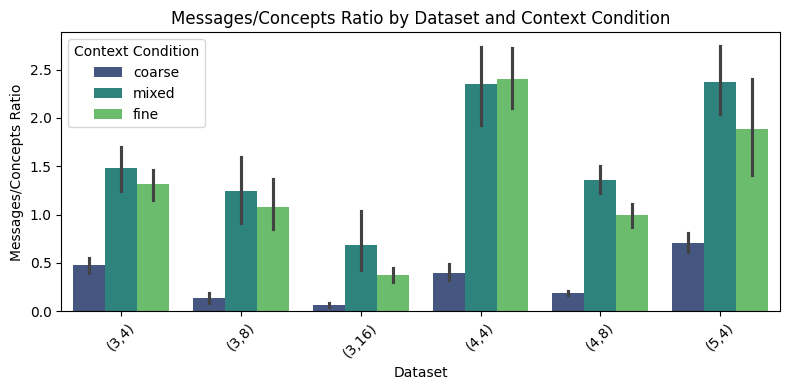

In [18]:
### Display the number of messages that were used during tranining in each ocntext condition as a bar plot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('analysis/message_counts.csv')

# Convert the 'dataset' column to a string type for better visualization
data['dataset'] = data['dataset'].astype(str)

# Set the figure size for better readability
plt.figure(figsize=(8, 4))

# Create a bar plot
sns.barplot(x='dataset', y='messages/concepts', hue='context_condition', data=data, palette='viridis')

# Add titles and labels
plt.title('Messages/Concepts Ratio by Dataset and Context Condition')
plt.xlabel('Dataset')
plt.ylabel('Messages/Concepts Ratio')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.legend(title='Context Condition')
plt.show()

## Concepts and messages

### Explorative analysis

In [ ]:
# change this to generate samples for a specific granularity
granularity = 'coarse'


# go through all datasets
for i, d in enumerate(datasets):
        # select first run
        path_to_run = paths[i] + '/' + str(setting) +'/granularity_' + granularity +'/' + str(0) + '/'
            
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction_train)
        print(path_to_interaction_train)

        messages = interaction.message.argmax(dim=-1)
        messages = [msg.tolist() for msg in messages]
        sender_input = interaction.sender_input
        print(sender_input.shape)
        n_targets = int(sender_input.shape[1]/2)
        # get target objects and fixed vectors to re-construct concepts
        target_objects = sender_input[:, :n_targets]
        target_objects = k_hot_to_attributes(target_objects, n_values[i])
        # concepts are defined by a list of target objects (here one sampled target object) and a fixed vector
        (objects, fixed) = retrieve_concepts_sampling(target_objects, all_targets=True)
        concepts = list(zip(objects, fixed))

        # get distractor objects to re-construct context conditions
        distractor_objects = sender_input[:, n_targets:]
        distractor_objects = k_hot_to_attributes(distractor_objects, n_values[i])
        context_conds = retrieve_context_condition(objects, fixed, distractor_objects)
        #print(context_conds)

        # get random qualitative samples
        #fixed_index = random.randint(0, n_attributes[i]-1) # define a fixed index for the concept
        #n_fixed = random.randint(1, n_attributes[i]) # how many fixed attributes?
        n_fixed =1
        #fixed_indices = random.sample(range(0, n_attributes[i]), k=n_fixed) # select which attributes are fixed
        fixed_indices = [0]
        #fixed_value = random.randint(0, n_values[i]-1) # define a fixed value for this index
        #fixed_values = random.choices(range(0, n_values[i]), k=n_fixed)
        fixed_values = [2]
        print(n_fixed, fixed_indices, fixed_values)
        #index_threshold = 20000 # optional: define some index threshold to make sure that examples are not taken from the beginning of training
        # TODO: adapt this loop such that multiple indices can be fixed
        all_for_this_concept = []
        for idx, (t_objects, t_fixed) in enumerate(concepts):
            #if sum(t_fixed) == 1 and t_fixed[fixed_index] == 1:# and idx > index_threshold:
            if sum(t_fixed) == n_fixed and all(t_fixed[fixed_index] == 1 for fixed_index in fixed_indices):
                for t_object in t_objects:
                    if all(t_object[fixed_index] == fixed_values[j] for j, fixed_index in enumerate(fixed_indices)):
                        all_for_this_concept.append((idx, t_object, t_fixed, context_conds[idx], messages[idx]))
                        fixed = t_fixed
        #print(all_for_this_concept)                
        if len(all_for_this_concept) > 0:
            #sample = random.sample(all_for_this_concept, 20)
            sample = all_for_this_concept
            column_names = ['game_nr', 'object', 'fixed indices', 'context condition', 'message']
            df = pd.DataFrame(sample, columns=column_names)
            df.to_csv('analysis/quali_' + str(d) + '_' + str(setting) + '_'+granularity +'_' + str(sample[0][1]) + ',' + str(fixed) + 'all.csv', index=False)
            print('saved ' + 'analysis/quali_' + str(d) + '_' + str(setting) +'_' + granularity+ '_' + str(sample[0][1]) + ',' + str(fixed) + 'all.csv')
        else:
            raise ValueError("sample for dataset " + str(d) + granularity + " could not be generated")

### Concepts for given messages in coarse context condition

In [19]:
import ast
def concepts_for_message(df, messages):
    '''this function displays all unique concepts that were referred to by a set of messages. 
       The option of giving more that one message can be useful to make a qualitative (and non-exahustive)
       first analysis of whether the languae may display positional features

    Args
        df (pandas dataframe) : dataframe conatning all the messages used during the last epoch of training and the concepts they were
                                used to refer to. These dataframes can be found under 'analysis\messages'
        messages (list[tuple]) 

    Returns
        list[tuple] : all the concepts that the messages were used to refer to
    '''
    concepts = []
    for message in messages:
        ex = df[df['message'] == str(message)]

        # Extract the concepts from the matching row
        concepts_str = ex.iloc[0, 1]
        # Convert the string representation of the tuple of lists to a Python object (tuple of lists)
        concepts_lists = ast.literal_eval(concepts_str)
        #immutable_data = [(tuple(item1), tuple(item2)) for item1, item2 in concepts_lists]
        #unique_concepts= list(immutable_data)
        for concept_tuple in set(concepts_lists):
            concepts.append(concept_tuple)
    return concepts

In [21]:
import os
from pathlib import Path
import torch
import pandas as pd

# Correct spelling: use strings
granularity_list = ['coarse', 'sampled_context', 'fine']

analysis_folder = Path('analysis')
messages_folder = analysis_folder / 'messages'
messages_folder.mkdir(parents=True, exist_ok=True)

context_name_map = {
    'coarse': 'coarse',
    'fine': 'fine',
    'sampled_context': 'mixed',
    'mixed': 'mixed_full',
}

# Optional typo protection
context_aliases = {
    'sampled_conmtext': 'sampled_context',
    'samples_context': 'sampled_context',
    'sample_context': 'sampled_context',
}


def get_run_path(base_path, setting, g, run):
    if g == 'mixed':
        return Path(base_path) / str(setting) / str(run)

    elif g == 'sampled_context':
        return Path(base_path) / str(setting) / 'sampled_context' / str(run)

    else:
        return Path(base_path) / str(setting) / f'granularity_{g}' / str(run)


def safe_name(x):
    return str(x).replace('/', '-').replace('\\', '-').replace(' ', '_')


for i, d in enumerate(datasets):
    for g_raw in granularity_list:

        # normalize possible typos
        g = context_aliases.get(str(g_raw), str(g_raw))
        context_label = context_name_map.get(g, g)

        for run in range(5):

            path_to_run = get_run_path(
                base_path=paths[i],
                setting=setting,
                g=g,
                run=run
            )

            path_to_interaction_train = (
                path_to_run
                / 'interactions'
                / 'train'
                / f'epoch_{n_epochs}'
                / 'interaction_gpu0'
            )

            if not path_to_interaction_train.exists():
                print(f"Missing file, skipping: {path_to_interaction_train}")
                continue

            interaction = torch.load(path_to_interaction_train)

            messages = interaction.message.argmax(dim=-1)
            messages = [msg.tolist() for msg in messages]

            sender_input = interaction.sender_input
            n_targets = int(sender_input.shape[1] / 2)

            # Get target objects and fixed vectors to reconstruct concepts
            target_objects = sender_input[:, :n_targets]
            target_objects = k_hot_to_attributes(target_objects, n_values[i])

            objects, fixed = retrieve_concepts_sampling(
                target_objects,
                all_targets=True
            )

            concepts = list(zip(objects, fixed))

            mess = []
            concept_reps = []

            for idx, (t_objects, t_fixed) in enumerate(concepts):
                concept_sample = (
                    list(int(x) for x in t_objects[0]),
                    list(int(x) for x in t_fixed)
                )

                mess.append(tuple(messages[idx]))
                concept_reps.append(
                    create_alternative_representation(concept_sample)
                )

            df = pd.DataFrame({
                'concepts': concept_reps,
                'message': mess
            })

            concept_df = df.groupby('concepts').agg({
                'message': lambda x: list(x)
            })

            print(
                f"{d} | {context_label} | run {run} | concept_df shape:",
                concept_df.shape
            )

            # Group by messages and aggregate concepts
            message_df = df.groupby('message', as_index=False).agg({
                'concepts': lambda x: list(x)
            })

            output_csv = (
                messages_folder
                / f"{safe_name(d)}_{safe_name(setting)}_{context_label}_run_{run}.csv"
            )

            message_df.to_csv(output_csv, index=False)

            print(f"Saved: {output_csv}")

(3,4) | coarse | run 0 | concept_df shape: (99, 1)
Saved: analysis\messages\(3,4)_standard_coarse_run_0.csv
(3,4) | coarse | run 1 | concept_df shape: (99, 1)
Saved: analysis\messages\(3,4)_standard_coarse_run_1.csv
(3,4) | coarse | run 2 | concept_df shape: (99, 1)
Saved: analysis\messages\(3,4)_standard_coarse_run_2.csv
(3,4) | coarse | run 3 | concept_df shape: (99, 1)
Saved: analysis\messages\(3,4)_standard_coarse_run_3.csv
(3,4) | coarse | run 4 | concept_df shape: (99, 1)
Saved: analysis\messages\(3,4)_standard_coarse_run_4.csv
(3,4) | mixed | run 0 | concept_df shape: (99, 1)
Saved: analysis\messages\(3,4)_standard_mixed_run_0.csv
(3,4) | mixed | run 1 | concept_df shape: (99, 1)
Saved: analysis\messages\(3,4)_standard_mixed_run_1.csv
(3,4) | mixed | run 2 | concept_df shape: (99, 1)
Saved: analysis\messages\(3,4)_standard_mixed_run_2.csv
(3,4) | mixed | run 3 | concept_df shape: (99, 1)
Saved: analysis\messages\(3,4)_standard_mixed_run_3.csv
(3,4) | mixed | run 4 | concept_df s

### D(3,4)

In [25]:
# Load DataFrame from CSV file
df = pd.read_csv('analysis/messages/(3,4)_standard_coarse_run_0.csv')
for c in concepts_for_message(df, [(4,4,4,0),]):
    print(c)

### fixed 3 is last postion 

(0, 1, 3)
(2, 1, 3)
(0, 3, 3)
('?', 2, 3)
(2, 3, 3)
('?', '?', 3)
(3, '?', 3)
(3, 2, 3)
(0, 2, 3)
('?', 1, 3)
(0, '?', 3)
(2, 0, 3)
(2, 2, 3)
(1, '?', 3)
(3, 1, 3)
('?', 3, 3)
(2, '?', 3)
(1, 2, 3)
(3, 3, 3)


### Lexica 
Here we create lexica for all conetxt conditions and all runs.
Three kinds of lexica are created:
- The lexica named D_granualrity.csv coarse show which concepts were referred to by each message during the last epoch for training.
- The lexica named D_symbols_granularity_coarse.csv group the messages that are composed by the same set pf symbols in the same row.
- The lexica names D_clean_symbols_granularity_coarse.csv additionally merge the concepts that were referred by the same set of symbols under the most general concept that satifies  all those concepts, if possible.

In [26]:
def most_general(concepts):
    '''
    Looks for a concepts that is satified by all concepts in the input list, i.e. looks for the least general concept which can all input concepts belong to
    
    Args:
        concepts (list) : a list of concepts. They must be in the alternative form described in ''create_alternative_represenantion(concept)''
    
    Returns:
        tuple : the least general concept that satisfies all concepts in the input list. If there is no such concepts, a tuple of None values is returned

    Example:
        >>> most general concept([(1, ?, 2), (0, 0, 2)])
        (?, ?, 2)
    '''
    concepts = list(concepts)
    general = ['?']*len(concepts[0])
    for i in range(len(general)):
        nth_attr = [c[i] for c in concepts]
        most_common_count = max([nth_attr.count(v) for v in nth_attr])
        if most_common_count / len(nth_attr) >= 1:
            general[i] = max(set(nth_attr), key=nth_attr.count)
    return tuple(general)


In [27]:
import os

# Specify the directory path
directory_path = "analysis/lexica"

# Check if the directory exists
if not os.path.exists(directory_path):
    # If it doesn't exist, create the directory
    os.makedirs(directory_path)
    print(f"Directory '{directory_path}' created successfully.")
else:
    print(f"Directory '{directory_path}' already exists.")

Directory 'analysis/lexica' created successfully.


In [30]:
import os
from pathlib import Path
import pandas as pd

messages_folder = Path('analysis/messages')
lexica_folder = Path('analysis/lexica')
lexica_folder.mkdir(parents=True, exist_ok=True)

output_csv = lexica_folder / 'message_counts.csv'

context_name_map = {
    'coarse': 'coarse',
    'fine': 'fine',
    'sampled_context': 'mixed',
    'mixed': 'mixed_full',
}

context_aliases = {
    'sampled_conmtext': 'sampled_context',
    'samples_context': 'sampled_context',
    'sample_context': 'sampled_context',
}

def safe_name(x):
    return str(x).replace('/', '-').replace('\\', '-').replace(' ', '_')


rows = []

for d in datasets:
    for g_raw in granularity_list:

        g = context_aliases.get(str(g_raw), str(g_raw))
        context_label = context_name_map.get(g, g)

        for run in range(5):

            input_csv = (
                messages_folder
                / f"{safe_name(d)}_{safe_name(setting)}_{context_label}_run_{run}.csv"
            )

            if not input_csv.exists():
                print(f"Missing file, skipping: {input_csv}")
                continue

            df = pd.read_csv(input_csv)

            for row in df.itertuples(index=False):
                message = row.message

                # Keep your existing helper function
                concepts = concepts_for_message(df, [message])
                n_concepts = len(concepts)

                rows.append({
                    'dataset': d,
                    'context_condition': context_label,
                    'run': run,
                    'message': message,
                    'n_concepts': n_concepts
                })


res = pd.DataFrame(rows)
res.to_csv(output_csv, index=False)

print(f"Saved {len(res)} rows to {output_csv}")

Saved 172352 rows to analysis\lexica\message_counts.csv


# Polysemy merics

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ---- CONFIG ----
lexica_folder = Path("analysis/lexica")

# Your previous cell had a small typo: "message_countscsv".
# This handles both possible names.
possible_count_files = [
    lexica_folder / "message_counts.csv",
]

counts_csv = None
for p in possible_count_files:
    if p.exists():
        counts_csv = p
        break

if counts_csv is None:
    raise FileNotFoundError(
        "Could not find message_counts.csv or message_countscsv in analysis/lexica/"
    )

print(f"Reading counts from: {counts_csv}")

df_counts = pd.read_csv(counts_csv)

# Total number of possible concepts per dataset
TOTAL_CONCEPTS = {
    "(3,4)": 99,
    "(3,8)": 582,
    "(3,16)": 3929,
    "(4,4)": 499,
    "(4,8)": 5248,
    "(5,4)": 2499,
}

CONTEXT_ORDER = {
    "coarse": 0,
    "mixed": 1,
    "fine": 2,
    "mixed_full": 3,
}


def normalize_dataset_name(d):
    """
    Accepts both '(3,4)' and 'D(3,4)' and returns '(3,4)'.
    """
    d = str(d)
    if d.startswith("D"):
        d = d[1:]
    return d


def display_dataset_name(d):
    return "D" + normalize_dataset_name(d)


def gini(array):
    array = np.asarray(array, dtype=np.float64)
    if len(array) == 0:
        return np.nan

    if np.amin(array) < 0:
        array -= np.amin(array)

    array += 1e-12
    array = np.sort(array)

    n = len(array)
    index = np.arange(1, n + 1)

    return np.sum((2 * index - n - 1) * array) / (n * np.sum(array))


def compute_aci(n_concepts_array, top_fraction=0.10):
    """
    Fraction of total ambiguity carried by the top X% most ambiguous messages.
    """
    arr = np.asarray(n_concepts_array, dtype=np.float64)
    if len(arr) == 0:
        return np.nan

    total = arr.sum()
    if total == 0:
        return np.nan

    k = max(1, int(len(arr) * top_fraction))
    top_sum = np.sum(np.sort(arr)[-k:])

    return top_sum / total


def compute_metrics_for_group(group):
    dataset_norm = normalize_dataset_name(group["dataset"].iloc[0])

    if dataset_norm not in TOTAL_CONCEPTS:
        raise ValueError(f"Missing total concept count for dataset: {dataset_norm}")

    total_concepts = TOTAL_CONCEPTS[dataset_norm]

    poly_ratio = group["n_concepts"] / total_concepts

    return pd.Series({
        "MeanPolysemyRatio": poly_ratio.mean(),
        "MedianPolysemyRatio": poly_ratio.median(),
        "GiniPolysemy": gini(poly_ratio.values),
        "ACI": compute_aci(group["n_concepts"].values, top_fraction=0.10),
        "n_messages": len(group),
    })


# ----------------------------------------------------
# 1. Metrics per dataset × context × run
# ----------------------------------------------------
df_run_metrics = (
    df_counts
    .groupby(["dataset", "context_condition", "run"], as_index=False)
    .apply(compute_metrics_for_group)
    .reset_index(drop=True)
)

df_run_metrics["Dataset"] = df_run_metrics["dataset"].apply(display_dataset_name)
df_run_metrics["Context"] = df_run_metrics["context_condition"]

display(df_run_metrics)

# Optional: save per-run metrics
per_run_output = lexica_folder / "polysemy_metrics_per_run.csv"
df_run_metrics.to_csv(per_run_output, index=False)
print(f"Saved per-run metrics to: {per_run_output}")


# ----------------------------------------------------
# 2. Aggregate mean/std across runs
# ----------------------------------------------------
metric_cols = [
    "MeanPolysemyRatio",
    "MedianPolysemyRatio",
    "GiniPolysemy",
    "ACI",
    "n_messages",
]

df_summary = (
    df_run_metrics
    .groupby(["Dataset", "Context"], as_index=False)[metric_cols]
    .agg(["mean", "std"])
)

# Flatten multi-index columns
df_summary.columns = [
    col[0] if col[1] == "" else f"{col[0]}_{col[1]}"
    for col in df_summary.columns
]

# Sorting
df_summary["Dataset_order"] = df_summary["Dataset"].map({
    "D(3,4)": 0,
    "D(3,8)": 1,
    "D(3,16)": 2,
    "D(4,4)": 3,
    "D(4,8)": 4,
    "D(5,4)": 5,
})

df_summary["Context_order"] = df_summary["Context"].map(CONTEXT_ORDER)

df_summary = (
    df_summary
    .sort_values(["Dataset_order", "Context_order"])
    .drop(columns=["Dataset_order", "Context_order"])
)

print("\n=== SUMMARY TABLE: mean/std across runs ===")
display(df_summary)

summary_output = lexica_folder / "polysemy_metrics_summary.csv"
df_summary.to_csv(summary_output, index=False)
print(f"Saved summary metrics to: {summary_output}")


# ----------------------------------------------------
# 3. Pretty table with mean ± std strings
# ----------------------------------------------------
def mean_std_str(row, metric, decimals=4):
    mean = row[f"{metric}_mean"]
    std = row[f"{metric}_std"]

    if pd.isna(std):
        std = 0.0

    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"


df_pretty = pd.DataFrame({
    "Dataset": df_summary["Dataset"],
    "Context": df_summary["Context"],
    "MeanPolysemyRatio": df_summary.apply(
        lambda r: mean_std_str(r, "MeanPolysemyRatio", 6),
        axis=1
    ),
    "MedianPolysemyRatio": df_summary.apply(
        lambda r: mean_std_str(r, "MedianPolysemyRatio", 6),
        axis=1
    ),
    "GiniPolysemy": df_summary.apply(
        lambda r: mean_std_str(r, "GiniPolysemy", 3),
        axis=1
    ),
    "ACI": df_summary.apply(
        lambda r: mean_std_str(r, "ACI", 3),
        axis=1
    ),
    "n_messages": df_summary.apply(
        lambda r: mean_std_str(r, "n_messages", 1),
        axis=1
    ),
})

print("\n=== PRETTY SUMMARY TABLE ===")
display(df_pretty)

pretty_output = lexica_folder / "polysemy_metrics_summary_pretty.csv"
df_pretty.to_csv(pretty_output, index=False)
print(f"Saved pretty summary table to: {pretty_output}")


# ----------------------------------------------------
# 4. LaTeX rows
# ----------------------------------------------------
print("\n=== LaTeX rows ===")
for _, row in df_pretty.iterrows():
    print(
        f"{row['Dataset']} & {row['Context']} & "
        f"{row['MeanPolysemyRatio']} & "
        f"{row['MedianPolysemyRatio']} & "
        f"{row['GiniPolysemy']} & "
        f"{row['ACI']} \\\\"
    )

Reading counts from: analysis\lexica\message_counts.csv


,dataset,context_condition,run,MeanPolysemyRatio,MedianPolysemyRatio,GiniPolysemy,ACI,n_messages,Dataset,Context
0,"(3,16)",coarse,0,0.008448,0.000382,0.799470,0.580416,136.0,"D(3,16)",coarse
1,"(3,16)",coarse,1,0.003770,0.000509,0.793053,0.716082,408.0,"D(3,16)",coarse
2,"(3,16)",coarse,2,0.004911,0.000509,0.819301,0.764787,262.0,"D(3,16)",coarse
3,"(3,16)",coarse,3,0.006911,0.000509,0.827079,0.781658,155.0,"D(3,16)",coarse
4,"(3,16)",coarse,4,0.005333,0.000764,0.796927,0.722521,231.0,"D(3,16)",coarse
...,...,...,...,...,...,...,...,...,...,...
85,"(5,4)",mixed,0,0.000544,0.000400,0.213014,0.224474,5766.0,"D(5,4)",mixed
86,"(5,4)",mixed,1,0.000500,0.000400,0.167929,0.202655,4940.0,"D(5,4)",mixed
87,"(5,4)",mixed,2,0.000785,0.000400,0.359146,0.302951,4890.0,"D(5,4)",mixed
88,"(5,4)",mixed,3,0.000676,0.000400,0.304855,0.265439,6369.0,"D(5,4)",mixed


Saved per-run metrics to: analysis\lexica\polysemy_metrics_per_run.csv

=== SUMMARY TABLE: mean/std across runs ===


,Dataset,Context,MeanPolysemyRatio_mean,MeanPolysemyRatio_std,MedianPolysemyRatio_mean,MedianPolysemyRatio_std,GiniPolysemy_mean,GiniPolysemy_std,ACI_mean,ACI_std,n_messages_mean,n_messages_std
3,"D(3,4)",coarse,0.036368,0.003802,0.012121,0.004517,0.555000,0.021308,0.403645,0.034457,47.0,9.746794
5,"D(3,4)",mixed,0.016612,0.002365,0.011111,0.002259,0.283245,0.048937,0.252908,0.029636,146.6,29.795973
4,"D(3,4)",fine,0.011009,0.000199,0.010101,0.000000,0.076364,0.015178,0.170938,0.016184,130.2,19.677398
6,"D(3,8)",coarse,0.019498,0.008376,0.004639,0.001438,0.688933,0.028645,0.482095,0.124651,78.8,40.419055
8,"D(3,8)",mixed,0.004316,0.001059,0.002749,0.000941,0.368777,0.051793,0.272782,0.022751,721.8,240.754439
7,"D(3,8)",fine,0.002915,0.000720,0.002062,0.000768,0.261592,0.079056,0.232788,0.023224,629.8,188.053716
0,"D(3,16)",coarse,0.005875,0.001827,0.000534,0.000139,0.807166,0.015059,0.713093,0.079174,238.4,108.186413
2,"D(3,16)",mixed,0.001309,0.000520,0.000764,0.000180,0.505526,0.065814,0.359865,0.035003,2699.0,1653.708862
1,"D(3,16)",fine,0.001130,0.000213,0.000713,0.000114,0.481678,0.041894,0.337387,0.030117,1461.6,363.816300
9,"D(4,4)",coarse,0.010596,0.001821,0.004008,0.001417,0.654492,0.024705,0.582501,0.026965,196.2,53.653518


Saved summary metrics to: analysis\lexica\polysemy_metrics_summary.csv

=== PRETTY SUMMARY TABLE ===


,Dataset,Context,MeanPolysemyRatio,MedianPolysemyRatio,GiniPolysemy,ACI,n_messages
3,"D(3,4)",coarse,0.036368 ± 0.003802,0.012121 ± 0.004517,0.555 ± 0.021,0.404 ± 0.034,47.0 ± 9.7
5,"D(3,4)",mixed,0.016612 ± 0.002365,0.011111 ± 0.002259,0.283 ± 0.049,0.253 ± 0.030,146.6 ± 29.8
4,"D(3,4)",fine,0.011009 ± 0.000199,0.010101 ± 0.000000,0.076 ± 0.015,0.171 ± 0.016,130.2 ± 19.7
6,"D(3,8)",coarse,0.019498 ± 0.008376,0.004639 ± 0.001438,0.689 ± 0.029,0.482 ± 0.125,78.8 ± 40.4
8,"D(3,8)",mixed,0.004316 ± 0.001059,0.002749 ± 0.000941,0.369 ± 0.052,0.273 ± 0.023,721.8 ± 240.8
7,"D(3,8)",fine,0.002915 ± 0.000720,0.002062 ± 0.000768,0.262 ± 0.079,0.233 ± 0.023,629.8 ± 188.1
0,"D(3,16)",coarse,0.005875 ± 0.001827,0.000534 ± 0.000139,0.807 ± 0.015,0.713 ± 0.079,238.4 ± 108.2
2,"D(3,16)",mixed,0.001309 ± 0.000520,0.000764 ± 0.000180,0.506 ± 0.066,0.360 ± 0.035,2699.0 ± 1653.7
1,"D(3,16)",fine,0.001130 ± 0.000213,0.000713 ± 0.000114,0.482 ± 0.042,0.337 ± 0.030,1461.6 ± 363.8
9,"D(4,4)",coarse,0.010596 ± 0.001821,0.004008 ± 0.001417,0.654 ± 0.025,0.583 ± 0.027,196.2 ± 53.7


Saved pretty summary table to: analysis\lexica\polysemy_metrics_summary_pretty.csv

=== LaTeX rows ===
D(3,4) & coarse & 0.036368 ± 0.003802 & 0.012121 ± 0.004517 & 0.555 ± 0.021 & 0.404 ± 0.034 \\
D(3,4) & mixed & 0.016612 ± 0.002365 & 0.011111 ± 0.002259 & 0.283 ± 0.049 & 0.253 ± 0.030 \\
D(3,4) & fine & 0.011009 ± 0.000199 & 0.010101 ± 0.000000 & 0.076 ± 0.015 & 0.171 ± 0.016 \\
D(3,8) & coarse & 0.019498 ± 0.008376 & 0.004639 ± 0.001438 & 0.689 ± 0.029 & 0.482 ± 0.125 \\
D(3,8) & mixed & 0.004316 ± 0.001059 & 0.002749 ± 0.000941 & 0.369 ± 0.052 & 0.273 ± 0.023 \\
D(3,8) & fine & 0.002915 ± 0.000720 & 0.002062 ± 0.000768 & 0.262 ± 0.079 & 0.233 ± 0.023 \\
D(3,16) & coarse & 0.005875 ± 0.001827 & 0.000534 ± 0.000139 & 0.807 ± 0.015 & 0.713 ± 0.079 \\
D(3,16) & mixed & 0.001309 ± 0.000520 & 0.000764 ± 0.000180 & 0.506 ± 0.066 & 0.360 ± 0.035 \\
D(3,16) & fine & 0.001130 ± 0.000213 & 0.000713 ± 0.000114 & 0.482 ± 0.042 & 0.337 ± 0.030 \\
D(4,4) & coarse & 0.010596 ± 0.001821 & 0.004008

# Visualisation

In [55]:
import ast
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines


# -----------------------------
# Config
# -----------------------------

lexica_folder = Path("analysis/lexica")

context_name_map = {
    "coarse": "coarse",
    "fine": "fine",
    "sampled_context": "mixed",
    "mixed": "mixed_full",
}

context_display_map = {
    "coarse": "Coarse context",
    "mixed": "Mixed context",
    "fine": "Fine context",
    "mixed_full": "Mixed full context",
}

context_aliases = {
    "sampled_conmtext": "sampled_context",
    "samples_context": "sampled_context",
    "sample_context": "sampled_context",
}


def safe_name(x):
    return str(x).replace("/", "-").replace("\\", "-").replace(" ", "_")


def parse_fixed_attribute_values(x):
    """
    Handles both:
      "{('?', 1, '?')}"
      "('?', 1, '?')"
      "[('?', 1, '?')]"

    Returns a list of candidate fixed-attribute tuples/lists.
    """
    obj = ast.literal_eval(str(x))

    if isinstance(obj, set):
        candidates = list(obj)
    else:
        candidates = [obj]

    parsed = []

    for cand in candidates:
        # Sometimes it may be wrapped as [(...)]
        if (
            isinstance(cand, (list, tuple))
            and len(cand) == 1
            and isinstance(cand[0], (list, tuple))
        ):
            cand = cand[0]

        parsed.append(list(cand))

    return parsed


def is_most_generic(fixed_attributes):
    """
    Returns 1 if at least one fixed-attribute representation fixes exactly one attribute.
    Example:
      ('?', '?', 2, '?') -> most generic
      ('?', 1, 2, '?')  -> not most generic
    """
    try:
        candidates = parse_fixed_attribute_values(fixed_attributes)

        for attributes in candidates:
            unfixed_count = attributes.count("?")
            if unfixed_count == len(attributes) - 1:
                return 1

        return 0

    except Exception as e:
        print(f"Error processing row: {fixed_attributes}, {e}")
        return 0

In [56]:
import re

rows = []

def extract_A_V(dataset_name):
    """
    Extracts A and V from labels like:
      (3,4)
      D(3,4)
      $D(3,4)$
    """
    match = re.search(r"(\d+)\s*,\s*(\d+)", str(dataset_name))
    if match is None:
        raise ValueError(f"Could not extract A,V from dataset name: {dataset_name}")
    return int(match.group(1)), int(match.group(2))


for d in datasets:
    for g_raw in granularity_list:

        g = context_aliases.get(str(g_raw), str(g_raw))
        context_label = context_name_map.get(g, g)
        context_display = context_display_map.get(context_label, context_label)

        for run in range(5):

            lexicon_path = (
                lexica_folder
                / f"{safe_name(d)}_{safe_name(setting)}_{context_label}_run_{run}.csv"
            )

            if not lexicon_path.exists():
                print(f"Missing file, skipping: {lexicon_path}")
                continue

            lexicon = pd.read_csv(lexicon_path)

            if "fixed_attribute_values" in lexicon.columns:
                fixed_col = "fixed_attribute_values"
            elif "fixed attribute values" in lexicon.columns:
                fixed_col = "fixed attribute values"
            else:
                raise ValueError(f"No fixed-attribute column found in {lexicon_path}")

            A, V = extract_A_V(d)
            total_possible_concepts = (V + 1) ** A - 1

            if total_possible_concepts == 0:
                print(f"No possible concepts for dataset {d}, skipping.")
                continue

            # Here count = number of concepts referred to by this message.
            # Therefore this is message-level concept coverage.
            lexicon["Ratio"] = lexicon["count"] / total_possible_concepts

            lexicon["Generic"] = lexicon[fixed_col].apply(is_most_generic)
            lexicon["Dataset"] = str(d)
            lexicon["Granularity"] = context_display
            lexicon["Context"] = context_label
            lexicon["Run"] = run

            rows.append(
                lexicon[
                    [
                        "Dataset",
                        "Granularity",
                        "Context",
                        "Run",
                        "Ratio",
                        "Generic",
                    ]
                ]
            )


data = pd.concat(rows, ignore_index=True)

print(data.groupby(["Dataset", "Granularity", "Run"]).size())
display(data.head())

Dataset  Granularity     Run
(3,16)   Coarse context  0       136
                         1       408
                         2       262
                         3       155
                         4       231
                                ... 
(5,4)    Mixed context   0      5766
                         1      4940
                         2      4890
                         3      6369
                         4      7679
Length: 90, dtype: int64


,Dataset,Granularity,Context,Run,Ratio,Generic
0,"(3,4)",Coarse context,coarse,0,0.032258,1
1,"(3,4)",Coarse context,coarse,0,0.016129,1
2,"(3,4)",Coarse context,coarse,0,0.008065,0
3,"(3,4)",Coarse context,coarse,0,0.008065,0
4,"(3,4)",Coarse context,coarse,0,0.008065,0


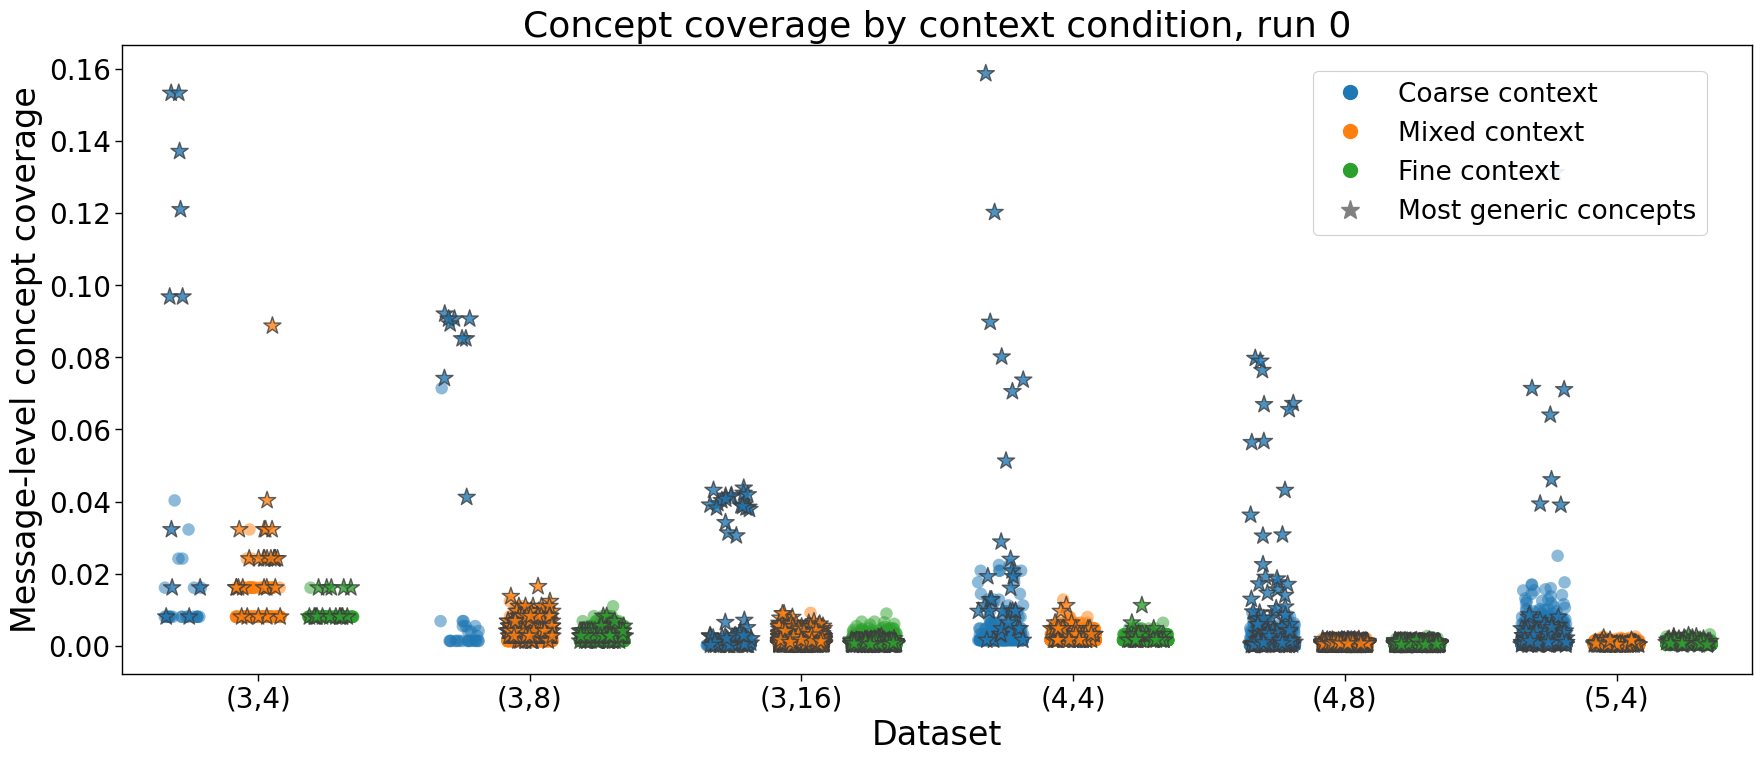

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# -----------------------------
# Choose the run to plot
# -----------------------------
run_to_plot = 0

data_run = data[data["Run"] == run_to_plot].copy()

if data_run.empty:
    raise ValueError(f"No data found for run {run_to_plot}")

# Stable dataset order
dataset_order = [str(d) for d in datasets]
dataset_order = [d for d in dataset_order if d in data_run["Dataset"].unique()]

# Stable context order
context_order = [
    "Coarse context",
    "Mixed context",
    "Fine context",
    "Mixed full context",
]

# Keep only contexts actually present in this run
context_order = [c for c in context_order if c in data_run["Granularity"].unique()]

# Bigger fonts
sns.set_context(
    "paper",
    font_scale=2.0,
    rc={
        "axes.labelsize": 24,
        "axes.titlesize": 26,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 19,
    },
)

# Wider and taller plot
plt.figure(figsize=(18, 8))

palette = dict(
    zip(
        context_order,
        sns.color_palette("tab10", n_colors=len(context_order))
    )
)

# -----------------------------
# Non-generic concepts
# -----------------------------
ax = sns.stripplot(
    x="Dataset",
    y="Ratio",
    hue="Granularity",
    data=data_run[data_run["Generic"] == 0],
    order=dataset_order,
    hue_order=context_order,
    palette=palette,
    dodge=True,
    marker="o",
    size=9,
    alpha=0.5,
    jitter=0.25,
)

# -----------------------------
# Most generic concepts
# -----------------------------
sns.stripplot(
    x="Dataset",
    y="Ratio",
    hue="Granularity",
    data=data_run[data_run["Generic"] == 1],
    order=dataset_order,
    hue_order=context_order,
    palette=palette,
    dodge=True,
    marker="*",
    size=13,
    alpha=0.8,
    linewidth=1,
    jitter=0.25,
    legend=False,
)

# Remove Seaborn automatic legend
if ax.legend_ is not None:
    ax.legend_.remove()

# -----------------------------
# Custom legend
# -----------------------------
context_handles = [
    mlines.Line2D(
        [],
        [],
        color=palette[c],
        marker="o",
        linestyle="None",
        markersize=10,
        label=c,
    )
    for c in context_order
]

generic_handle = mlines.Line2D(
    [],
    [],
    color="gray",
    marker="*",
    linestyle="None",
    markersize=14,
    label="Most generic concepts",
)

plt.legend(
    handles=context_handles + [generic_handle],
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=True,
    framealpha=0.9,
    fontsize=19,
)

# -----------------------------
# Labels and layout
# -----------------------------
plt.ylabel("Message-level concept coverage", fontsize=24)
plt.xlabel("Dataset", fontsize=24)
plt.title(f"Concept coverage by context condition, run {run_to_plot}", fontsize=26)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.tight_layout()
plt.show()

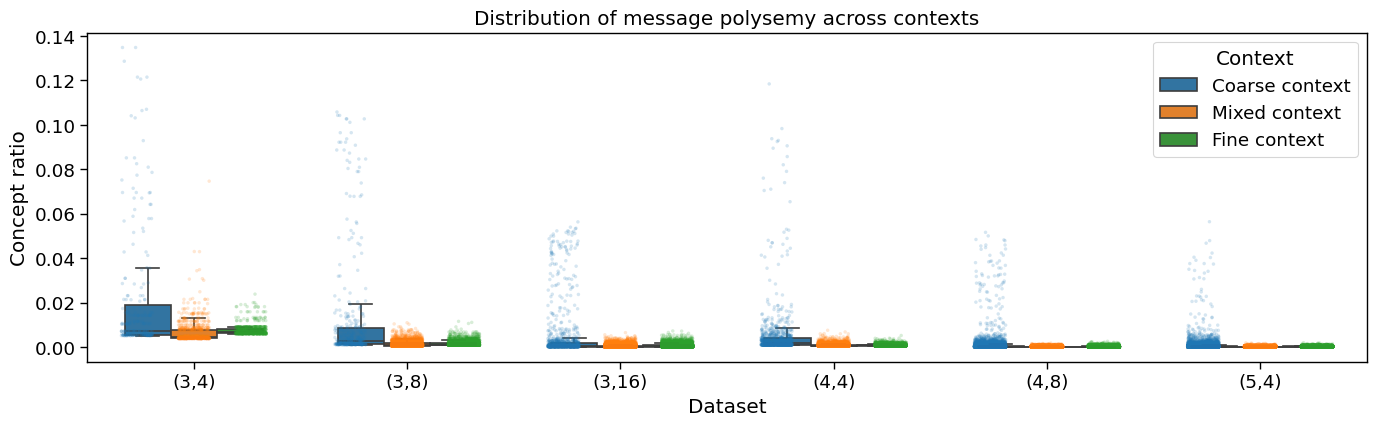

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=1.5)

hue_order = [
    "Coarse context",
    "Mixed context",
    "Fine context",
    "Mixed full context",
]

hue_order = [h for h in hue_order if h in data["Granularity"].unique()]

plt.figure(figsize=(14, 4.5))

sns.boxplot(
    x="Dataset",
    y="Ratio",
    hue="Granularity",
    data=data,
    hue_order=hue_order,
    showfliers=False,
    width=0.65,
    linewidth=1.2,
)

sns.stripplot(
    x="Dataset",
    y="Ratio",
    hue="Granularity",
    data=data,
    hue_order=hue_order,
    dodge=True,
    size=2.5,
    alpha=0.18,
    jitter=0.22,
    legend=False,
)

plt.ylabel("Concept ratio")
plt.xlabel("Dataset")
plt.title("Distribution of message polysemy across contexts")

handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))

plt.legend(
    [unique[h] for h in hue_order],
    hue_order,
    title="Context",
    loc="upper right",
)

plt.tight_layout()
plt.show()